<a href="https://colab.research.google.com/github/shreeshbastakoti041-max/Volatility-Regime-Detection-Model-ICCUR-SUMMER-FELLOWSHIP/blob/main/Robustness_Check_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# ROBUSTNESS CHECKS
# BLOCK 1 — COMPLETE MODEL SETUP
# ================================================================

# Install missing packages (run only once)
try:
    from hmmlearn.hmm import GaussianHMM
except ModuleNotFoundError:
    !pip -q install hmmlearn yfinance scikit-learn

# ================================================================
# Imports
# ================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM

np.random.seed(42)

print("="*70)
print("ROBUSTNESS MODEL SETUP")
print("="*70)

# ================================================================
# Download SPY Data
# ================================================================

data = yf.download(
    "SPY",
    start="2004-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=False
)

# Flatten columns if needed
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# ================================================================
# Feature Engineering
# ================================================================

data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

data["rv_20"] = (
    data["log_return"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

data["volume_change"] = data["Volume"].pct_change()

data["vol_of_vol"] = (
    data["rv_20"]
    .rolling(20)
    .std()
)

data["rolling_kurtosis"] = (
    data["log_return"]
    .rolling(20)
    .kurt()
)

FEATURES = [
    "log_return",
    "rv_20",
    "rolling_kurtosis",
    "volume_change",
    "vol_of_vol"
]

# ================================================================
# Clean Dataset
# ================================================================

data = data.dropna(subset=FEATURES).copy()

# ================================================================
# Train / Test Split
# ================================================================

train_data = data[data.index.year <= 2024].copy()
test_data  = data[data.index.year == 2025].copy()

print(f"\nTraining observations : {len(train_data)}")
print(f"Testing observations  : {len(test_data)}")

# ================================================================
# Standardization
# ================================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(train_data[FEATURES])

# ================================================================
# GMM (3 Components)
# ================================================================

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=10
)

gmm.fit(X_train)

# ================================================================
# HMM (Warm Start)
# ================================================================

hmm_model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    init_params=""
)

# Uniform initialization
hmm_model.startprob_ = np.ones(3) / 3

hmm_model.transmat_ = np.ones((3, 3)) / 3

# Warm start using GMM
hmm_model.means_ = gmm.means_
hmm_model.covars_ = gmm.covariances_

# Train HMM
hmm_model.fit(X_train)

# ================================================================
# Predict Hidden States
# ================================================================

train_data["hmm_state"] = hmm_model.predict(X_train)

# ================================================================
# Regime Mapping
# ================================================================

profile = train_data.groupby("hmm_state")[FEATURES].mean()

order = profile["rv_20"].sort_values().index

regime_map = {
    order[0]: "Low Vol",
    order[1]: "Medium Vol",
    order[2]: "High Vol"
}

train_data["regime"] = train_data["hmm_state"].map(regime_map)

# ================================================================
# Summary
# ================================================================

print("\n")
print("="*70)
print("MODEL READY")
print("="*70)

print("\nFeatures Used")
print(FEATURES)

print("\nRegime Mapping")

for state, label in regime_map.items():
    print(f"State {state} → {label}")

print("\nTraining Regime Distribution (%)")

print(
    (
        train_data["regime"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

print("\nTransition Matrix")

print(
    pd.DataFrame(
        hmm_model.transmat_.round(3),
        index=[f"From {i}" for i in range(3)],
        columns=[f"To {i}" for i in range(3)]
    )
)

print("\nAverage Persistence:",
      round(np.mean(np.diag(hmm_model.transmat_)),3))

print("\n✓ Data downloaded")
print("✓ Features engineered")
print("✓ StandardScaler fitted")
print("✓ GMM trained")
print("✓ HMM trained")
print("✓ Regimes labeled")
print("✓ Ready for robustness experiments")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 9.7 MB/s eta 0:00:00
ROBUSTNESS MODEL SETUP

Training observations : 5246
Testing observations  : 249


MODEL READY

Features Used
['log_return', 'rv_20', 'rolling_kurtosis', 'volume_change', 'vol_of_vol']

Regime Mapping
State 0 → Low Vol
State 1 → Medium Vol
State 2 → High Vol

Training Regime Distribution (%)
regime
High Vol      11.65
Low Vol       40.56
Medium Vol    47.79
Name: proportion, dtype: float64

Transition Matrix
         To 0   To 1   To 2
From 0  0.971  0.029  0.000
From 1  0.024  0.967  0.009
From 2  0.000  0.035  0.965

Average Persistence: 0.967

✓ Data downloaded
✓ Features engineered
✓ StandardScaler fitted
✓ GMM trained
✓ HMM trained
✓ Regimes labeled
✓ Ready for robustness experiments


In [ ]:
# ============================================================
# ROBUSTNESS TEST 1
# Train : 2022-2024
# Test  : 2025
# ============================================================

import yfinance as yf
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM

np.random.seed(42)

print("="*70)
print("ROBUSTNESS TEST : 3-YEAR TRAINING WINDOW")
print("="*70)

# ------------------------------------------------------------
# Download Data
# ------------------------------------------------------------

spy = yf.download(
    "SPY",
    start="2022-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=False
)

# ------------------------------------------------------------
# FIX MultiIndex (new versions of yfinance)
# ------------------------------------------------------------

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

print("\nColumns")
print(spy.columns)

spy = spy[["Open","High","Low","Close","Volume"]].copy()

# ------------------------------------------------------------
# Feature Engineering
# ------------------------------------------------------------

spy["log_return"] = np.log(spy["Close"]/spy["Close"].shift(1))

spy["rv_20"] = spy["log_return"].rolling(20).std()

spy["rolling_kurtosis"] = (
    spy["log_return"]
        .rolling(20)
        .kurt()
)

spy["volume_change"] = spy["Volume"].pct_change()

spy["vol_of_vol"] = (
    spy["rv_20"]
        .rolling(20)
        .std()
)

FEATURES = [
    "log_return",
    "rv_20",
    "rolling_kurtosis",
    "volume_change",
    "vol_of_vol"
]

spy = spy.dropna(subset=FEATURES).copy()

# ------------------------------------------------------------
# Train/Test Split
# ------------------------------------------------------------

train = spy.loc["2022":"2024"].copy()
test  = spy.loc["2025"].copy()

print("\nTraining Rows :", len(train))
print("Testing Rows  :", len(test))

ROBUSTNESS TEST : 3-YEAR TRAINING WINDOW

Columns
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

Training Rows : 714
Testing Rows  : 249


In [ ]:
# ============================================================
# BLOCK 2 — STANDARDIZATION
# ============================================================

print("="*70)
print("STANDARDIZATION")
print("="*70)

FEATURES = [
    "log_return",
    "rv_20",
    "rolling_kurtosis",
    "volume_change",
    "vol_of_vol"
]

scaler = StandardScaler()

X_train = scaler.fit_transform(train[FEATURES])
X_test = scaler.transform(test[FEATURES])

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nScaled Training Statistics")
print(pd.DataFrame(
    X_train,
    columns=FEATURES
).describe().round(3))

print("\n✓ StandardScaler fitted on training data.")
print("✓ Test data transformed using training scaler.")
print("✓ Ready for GMM.")

STANDARDIZATION

Training Shape : (714, 5)
Testing Shape  : (249, 5)

Scaled Training Statistics
       log_return    rv_20  rolling_kurtosis  volume_change  vol_of_vol
count     714.000  714.000           714.000        714.000     714.000
mean        0.000    0.000             0.000          0.000       0.000
std         1.001    1.001             1.001          1.001       1.001
min        -4.118   -1.582            -1.139         -2.359      -1.206
25%        -0.526   -0.762            -0.666         -0.692      -0.688
50%         0.004   -0.305            -0.323         -0.152      -0.360
75%         0.557    0.559             0.444          0.567       0.459
max         4.860    2.845             6.816          5.581       4.068

✓ StandardScaler fitted on training data.
✓ Test data transformed using training scaler.
✓ Ready for GMM.


In [ ]:
# ============================================================
# BLOCK 3 — GMM
# ============================================================

print("="*70)
print("GAUSSIAN MIXTURE MODEL")
print("="*70)

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=10
)

gmm.fit(X_train)

train["gmm_state"] = gmm.predict(X_train)
test["gmm_state"] = gmm.predict(X_test)

print("\nLog Likelihood :", round(gmm.score(X_train),4))

print("\nCluster Counts")
print(train["gmm_state"].value_counts().sort_index())

print("\nCluster Percentages (%)")
print(
    train["gmm_state"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

profile = (
    train
    .groupby("gmm_state")[FEATURES]
    .mean()
)

print("\nCluster Profile")
print(profile.round(3))

print("\n✓ GMM fitted successfully.")
print("✓ Warm start parameters ready for HMM.")

GAUSSIAN MIXTURE MODEL

Log Likelihood : -6.0177

Cluster Counts
gmm_state
0    240
1    283
2    191
Name: count, dtype: int64

Cluster Percentages (%)
gmm_state
0    33.61
1    39.64
2    26.75
Name: proportion, dtype: float64

Cluster Profile
Price      log_return  rv_20  rolling_kurtosis  volume_change  vol_of_vol
gmm_state                                                                
0              -0.000  0.014             0.390          0.108       0.002
1               0.001  0.009            -0.672          0.060       0.001
2               0.001  0.007             1.363         -0.072       0.001

✓ GMM fitted successfully.
✓ Warm start parameters ready for HMM.


In [ ]:
# ============================================================
# BLOCK 4 — HMM
# ============================================================

print("="*70)
print("HIDDEN MARKOV MODEL")
print("="*70)

hmm_model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    init_params=""
)

# Warm start from GMM
hmm_model.startprob_ = np.ones(3) / 3
hmm_model.transmat_ = np.ones((3,3)) / 3
hmm_model.means_ = gmm.means_
hmm_model.covars_ = gmm.covariances_

hmm_model.fit(X_train)

train["hmm_state"] = hmm_model.predict(X_train)
test["hmm_state"] = hmm_model.predict(X_test)

print("\nLog Likelihood :", round(hmm_model.score(X_train),2))

print("\nState Counts")
print(train["hmm_state"].value_counts().sort_index())

print("\nTransition Matrix")

transition = pd.DataFrame(
    hmm_model.transmat_,
    index=[f"From {i}" for i in range(3)],
    columns=[f"To {i}" for i in range(3)]
)

print(transition.round(3))

print("\n✓ HMM trained successfully.")
print("✓ Ready for regime labeling.")

HIDDEN MARKOV MODEL

Log Likelihood : -3701.37

State Counts
hmm_state
0    206
1    258
2    250
Name: count, dtype: int64

Transition Matrix
         To 0   To 1   To 2
From 0  0.981  0.015  0.005
From 1  0.012  0.973  0.016
From 2  0.004  0.012  0.984

✓ HMM trained successfully.
✓ Ready for regime labeling.


In [ ]:
# ============================================================
# BLOCK 5 — REGIME LABELING
# ============================================================

print("="*70)
print("REGIME LABELING")
print("="*70)

profile = (
    train
    .groupby("hmm_state")[FEATURES]
    .mean()
)

print("\nState Profile")
print(profile.round(3))

order = profile["rv_20"].sort_values().index

regime_map = {
    order[0]: "Low Vol",
    order[1]: "Medium Vol",
    order[2]: "High Vol"
}

train["regime"] = train["hmm_state"].map(regime_map)
test["regime"] = test["hmm_state"].map(regime_map)

print("\nRegime Mapping")

for k, v in regime_map.items():
    print(f"State {k} -> {v}")

print("\nTraining Regime Distribution (%)")
print(
    train["regime"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting Regime Distribution (%)")
print(
    test["regime"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n✓ Hidden states labeled.")
print("✓ Ready for transition analysis.")

REGIME LABELING

State Profile
Price      log_return  rv_20  rolling_kurtosis  volume_change  vol_of_vol
hmm_state                                                                
0              -0.000  0.015             0.342          0.048       0.002
1               0.001  0.010            -0.731          0.024       0.001
2               0.001  0.007             1.127          0.051       0.001

Regime Mapping
State 2 -> Low Vol
State 1 -> Medium Vol
State 0 -> High Vol

Training Regime Distribution (%)
regime
Medium Vol    36.13
Low Vol       35.01
High Vol      28.85
Name: proportion, dtype: float64

Testing Regime Distribution (%)
regime
Low Vol       54.22
High Vol      28.92
Medium Vol    16.87
Name: proportion, dtype: float64

✓ Hidden states labeled.
✓ Ready for transition analysis.


In [ ]:
# ============================================================
# BLOCK 6 — BAYESIAN TRANSITION ANALYSIS
# ============================================================

print("="*70)
print("BAYESIAN TRANSITION ANALYSIS")
print("="*70)

# ------------------------------------------------------------
# Transition Counts
# ------------------------------------------------------------

n_states = hmm_model.n_components

transition_counts = np.zeros((n_states, n_states), dtype=int)

states = train["hmm_state"].values

for i in range(len(states)-1):
    transition_counts[states[i], states[i+1]] += 1

print("\nObserved Transition Counts")

print(pd.DataFrame(
    transition_counts,
    index=[f"From {i}" for i in range(n_states)],
    columns=[f"To {i}" for i in range(n_states)]
))

# ------------------------------------------------------------
# Bayesian Smoothing
# ------------------------------------------------------------

alpha = np.ones((n_states, n_states))
np.fill_diagonal(alpha, 10)

posterior = transition_counts + alpha

bayes_transition = posterior / posterior.sum(axis=1, keepdims=True)

print("\nBayesian Transition Matrix")

print(pd.DataFrame(
    bayes_transition.round(3),
    index=[f"From {i}" for i in range(n_states)],
    columns=[f"To {i}" for i in range(n_states)]
))

# ------------------------------------------------------------
# Persistence & Duration
# ------------------------------------------------------------

summary = []

for i in range(n_states):

    stay = bayes_transition[i, i]
    exit_prob = 1 - stay
    duration = 1 / exit_prob

    summary.append([
        regime_map[i],
        stay,
        exit_prob,
        duration
    ])

summary = pd.DataFrame(
    summary,
    columns=[
        "Regime",
        "Persistence",
        "Exit Probability",
        "Expected Duration"
    ]
)

summary["Persistence"] = summary["Persistence"].round(3)
summary["Exit Probability"] = summary["Exit Probability"].round(3)
summary["Expected Duration"] = summary["Expected Duration"].round(2)

print("\nRegime Statistics")

print(summary)

print("\nAverage Persistence:",
      round(summary["Persistence"].mean(),3))

print("\n✓ Bayesian transition analysis completed.")
print("✓ Ready to compare with the 21-year model.")

BAYESIAN TRANSITION ANALYSIS

Observed Transition Counts
        To 0  To 1  To 2
From 0   202     3     1
From 1     3   251     4
From 2     1     3   245

Bayesian Transition Matrix
         To 0   To 1   To 2
From 0  0.972  0.018  0.009
From 1  0.015  0.967  0.019
From 2  0.008  0.015  0.977

Regime Statistics
       Regime  Persistence  Exit Probability  Expected Duration
0    High Vol        0.972             0.028              36.33
1  Medium Vol        0.967             0.033              30.00
2     Low Vol        0.977             0.023              43.50

Average Persistence: 0.972

✓ Bayesian transition analysis completed.
✓ Ready to compare with the 21-year model.


OUT-OF-SAMPLE VALIDATION (2025)

Rows in Test Set : 249

Hidden State Counts
hmm_state
0     72
1     42
2    135
Name: count, dtype: int64

Regime Counts
regime
Low Vol       135
High Vol       72
Medium Vol     42
Name: count, dtype: int64

Regime Percentages (%)
regime
Low Vol       54.22
High Vol      28.92
Medium Vol    16.87
Name: proportion, dtype: float64


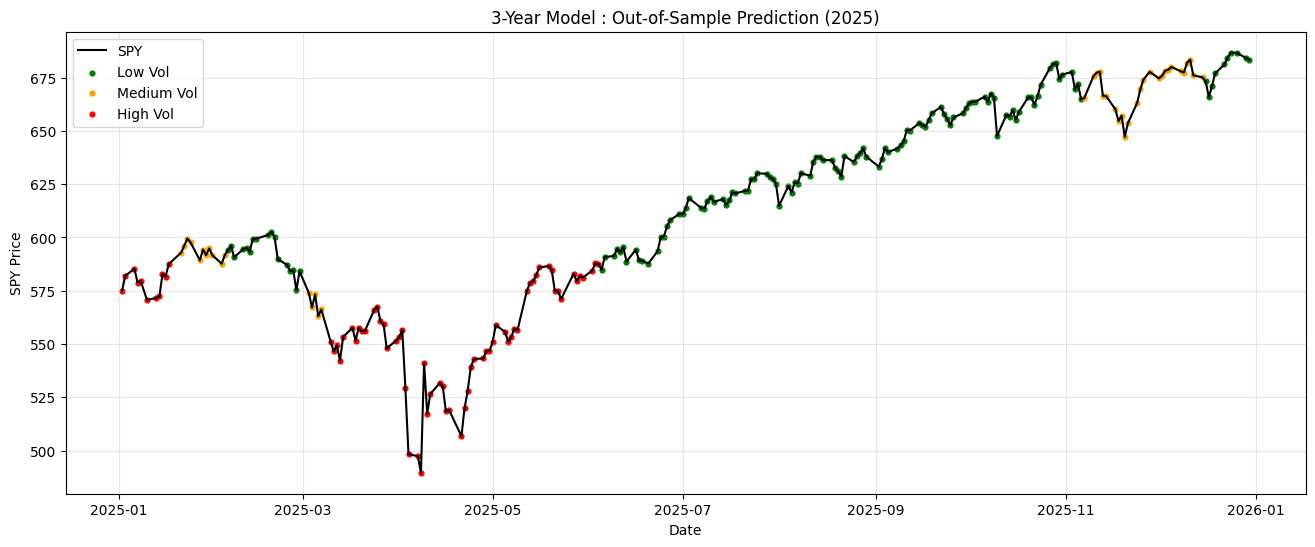


✓ Hidden states predicted on unseen data.
✓ Ready for robustness comparison.


In [ ]:
# ============================================================
# BLOCK 7 — OUT-OF-SAMPLE VALIDATION (2025)
# ============================================================

print("="*75)
print("OUT-OF-SAMPLE VALIDATION (2025)")
print("="*75)

# ------------------------------------------------------------
# Scale test features using TRAIN scaler
# ------------------------------------------------------------

X_test = scaler.transform(test[FEATURES])

# ------------------------------------------------------------
# Predict hidden states
# ------------------------------------------------------------

test["hmm_state"] = hmm_model.predict(X_test)

# ------------------------------------------------------------
# Convert hidden states to regime names
# ------------------------------------------------------------

test["regime"] = test["hmm_state"].map(regime_map)

print("\nRows in Test Set :", len(test))

print("\nHidden State Counts")
print(test["hmm_state"].value_counts().sort_index())

print("\nRegime Counts")
print(test["regime"].value_counts())

print("\nRegime Percentages (%)")
print(
    (test["regime"]
     .value_counts(normalize=True)
     .mul(100)
     .round(2))
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(16,6))

colors = {
    "Low Vol":"green",
    "Medium Vol":"orange",
    "High Vol":"red"
}

plt.plot(
    test.index,
    test["Close"],
    color="black",
    lw=1.5,
    label="SPY"
)

for regime, color in colors.items():

    mask = test["regime"] == regime

    plt.scatter(
        test.index[mask],
        test.loc[mask,"Close"],
        s=12,
        color=color,
        label=regime
    )

plt.title("3-Year Model : Out-of-Sample Prediction (2025)")
plt.xlabel("Date")
plt.ylabel("SPY Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("\n✓ Hidden states predicted on unseen data.")
print("✓ Ready for robustness comparison.")

Low Vol → Medium Vol transitions: 3


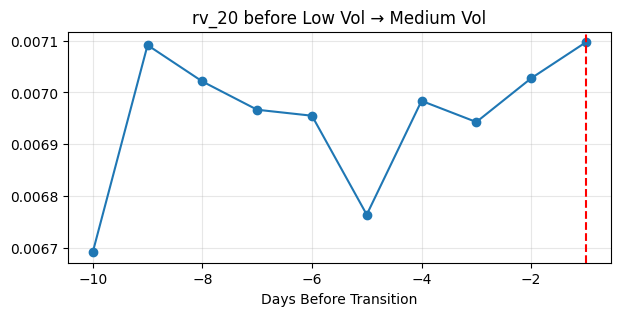

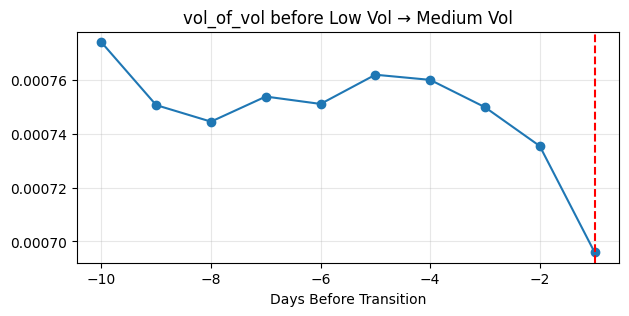

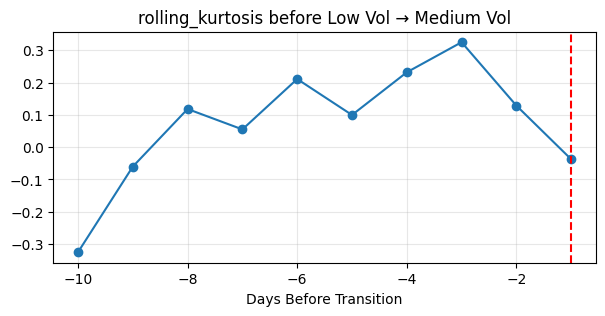

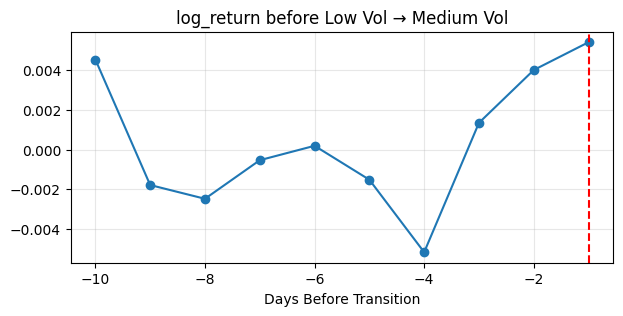

In [ ]:
# ============================================================
# EARLY WARNING ANALYSIS
# Average Feature Behavior Before Low -> Medium Transition
# ============================================================

LOOKBACK = 10

from_regime = "Low Vol"
to_regime   = "Medium Vol"

features = [
    "rv_20",
    "vol_of_vol",
    "rolling_kurtosis",
    "log_return"
]

transition_idx = []

for i in range(1, len(train)):
    if (
        train["regime"].iloc[i-1] == from_regime and
        train["regime"].iloc[i] == to_regime
    ):
        transition_idx.append(i)

print(f"{from_regime} → {to_regime} transitions:", len(transition_idx))

history = {f: [] for f in features}

for idx in transition_idx:

    if idx >= LOOKBACK:

        window = train.iloc[idx-LOOKBACK:idx]

        for f in features:
            history[f].append(window[f].values)

avg_history = {}

for f in features:
    avg_history[f] = np.mean(history[f], axis=0)

days = np.arange(-LOOKBACK,0)

for f in features:

    plt.figure(figsize=(7,3))

    plt.plot(days, avg_history[f], marker="o")

    plt.axvline(-1,color="red",linestyle="--")

    plt.title(f"{f} before {from_regime} → {to_regime}")

    plt.xlabel("Days Before Transition")

    plt.grid(alpha=.3)

    plt.show()

EARLY WARNING ANALYSIS
Transition Windows : 3
Stable Windows     : 245


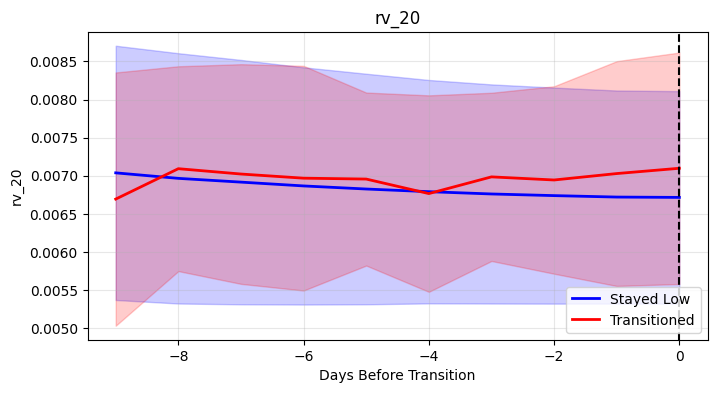

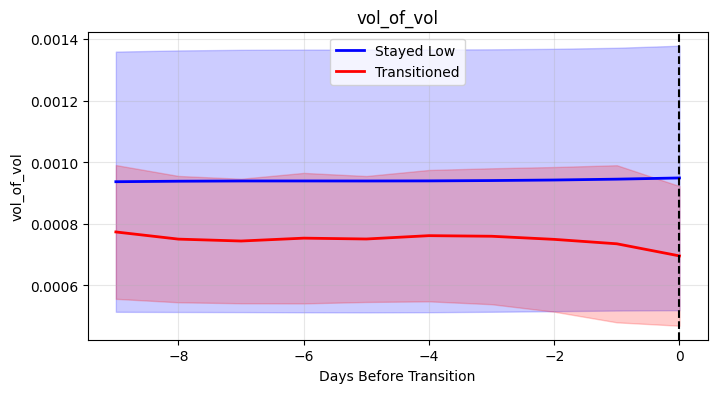

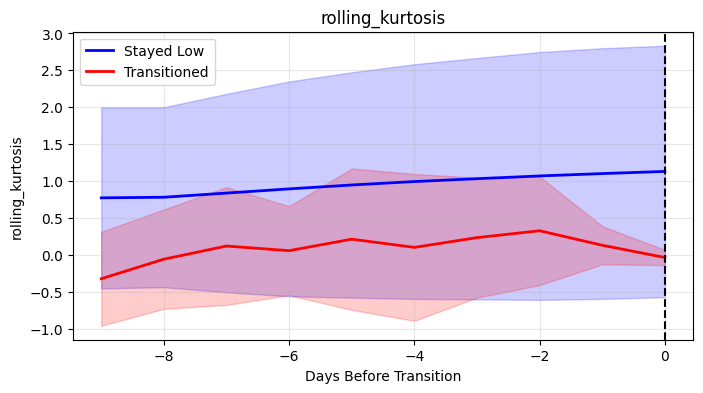

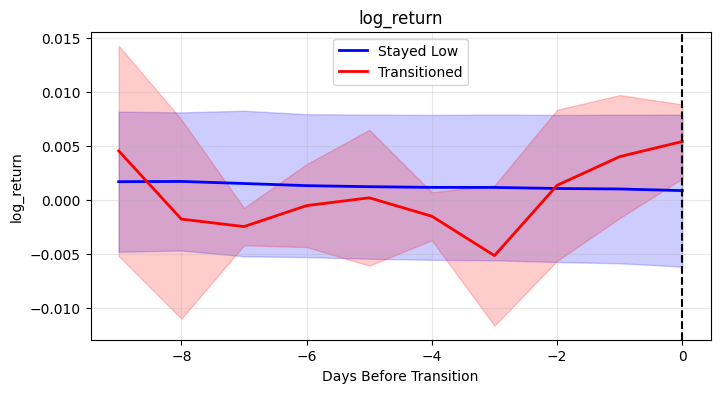

In [ ]:
# ============================================================
# TRANSITION VS STABLE LOW VOL
# WITH UNCERTAINTY BANDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

LOOKBACK = 10

features = [
    "rv_20",
    "vol_of_vol",
    "rolling_kurtosis",
    "log_return"
]

transition_windows = []
stable_windows = []

for i in range(LOOKBACK, len(train)-1):

    today = train["regime"].iloc[i]
    tomorrow = train["regime"].iloc[i+1]

    window = train.iloc[i-LOOKBACK+1:i+1]

    if len(window) != LOOKBACK:
        continue

    if today == "Low Vol" and tomorrow == "Medium Vol":
        transition_windows.append(window)

    elif today == "Low Vol" and tomorrow == "Low Vol":
        stable_windows.append(window)

print("="*70)
print("EARLY WARNING ANALYSIS")
print("="*70)
print("Transition Windows :", len(transition_windows))
print("Stable Windows     :", len(stable_windows))


days = np.arange(-LOOKBACK+1,1)

for feature in features:

    transition = np.array(
        [w[feature].values for w in transition_windows]
    )

    stable = np.array(
        [w[feature].values for w in stable_windows]
    )

    transition_mean = transition.mean(axis=0)
    transition_std  = transition.std(axis=0)

    stable_mean = stable.mean(axis=0)
    stable_std  = stable.std(axis=0)

    plt.figure(figsize=(8,4))

    # Stable
    plt.plot(
        days,
        stable_mean,
        lw=2,
        label="Stayed Low",
        color="blue"
    )

    plt.fill_between(
        days,
        stable_mean-stable_std,
        stable_mean+stable_std,
        alpha=.20,
        color="blue"
    )

    # Transition
    plt.plot(
        days,
        transition_mean,
        lw=2,
        label="Transitioned",
        color="red"
    )

    plt.fill_between(
        days,
        transition_mean-transition_std,
        transition_mean+transition_std,
        alpha=.20,
        color="red"
    )

    plt.axvline(
        0,
        color="black",
        linestyle="--"
    )

    plt.title(feature)

    plt.xlabel("Days Before Transition")

    plt.ylabel(feature)

    plt.grid(alpha=.3)

    plt.legend()

    plt.show()